## Machine Learning

🚀 Email Phishing Classification: Synthetic Data Augmentation Analysis
Research Question 3: How does adding synthetic data to real training data affect performance?
Base: 2K real training data
Augmentation: +0K, +0.1K, +0.2K, ..., +1.9K, +2K synthetic data
Total training sizes: 2K to 4K samples
Classifiers: SVM, Random Forest, XGBoost
📂 Data Files:
   Real Training: ../raw/email_phishing_CEAS-08_train.csv.gz
   Testing: ../raw/email_phishing_CEAS-08_test.csv.gz
   Synthetic: ../data/seeds-augment/email_phishing_CEAS-08_train_augment.csv.gz

🎯 Experimental Setup:
   Base real training size: 1,000 samples (constant)
   Synthetic augmentation amounts: [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
   Total training sizes: [1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]
   Cross-validation: 5-fold
   Random state: 42

📊 LOADING DATASETS

📥 Loading real training data from: ../raw/email_phishing_CEAS-08_train.csv.gz
   ✅ Loaded successfully!
   Shape: (2000, 4)
   C

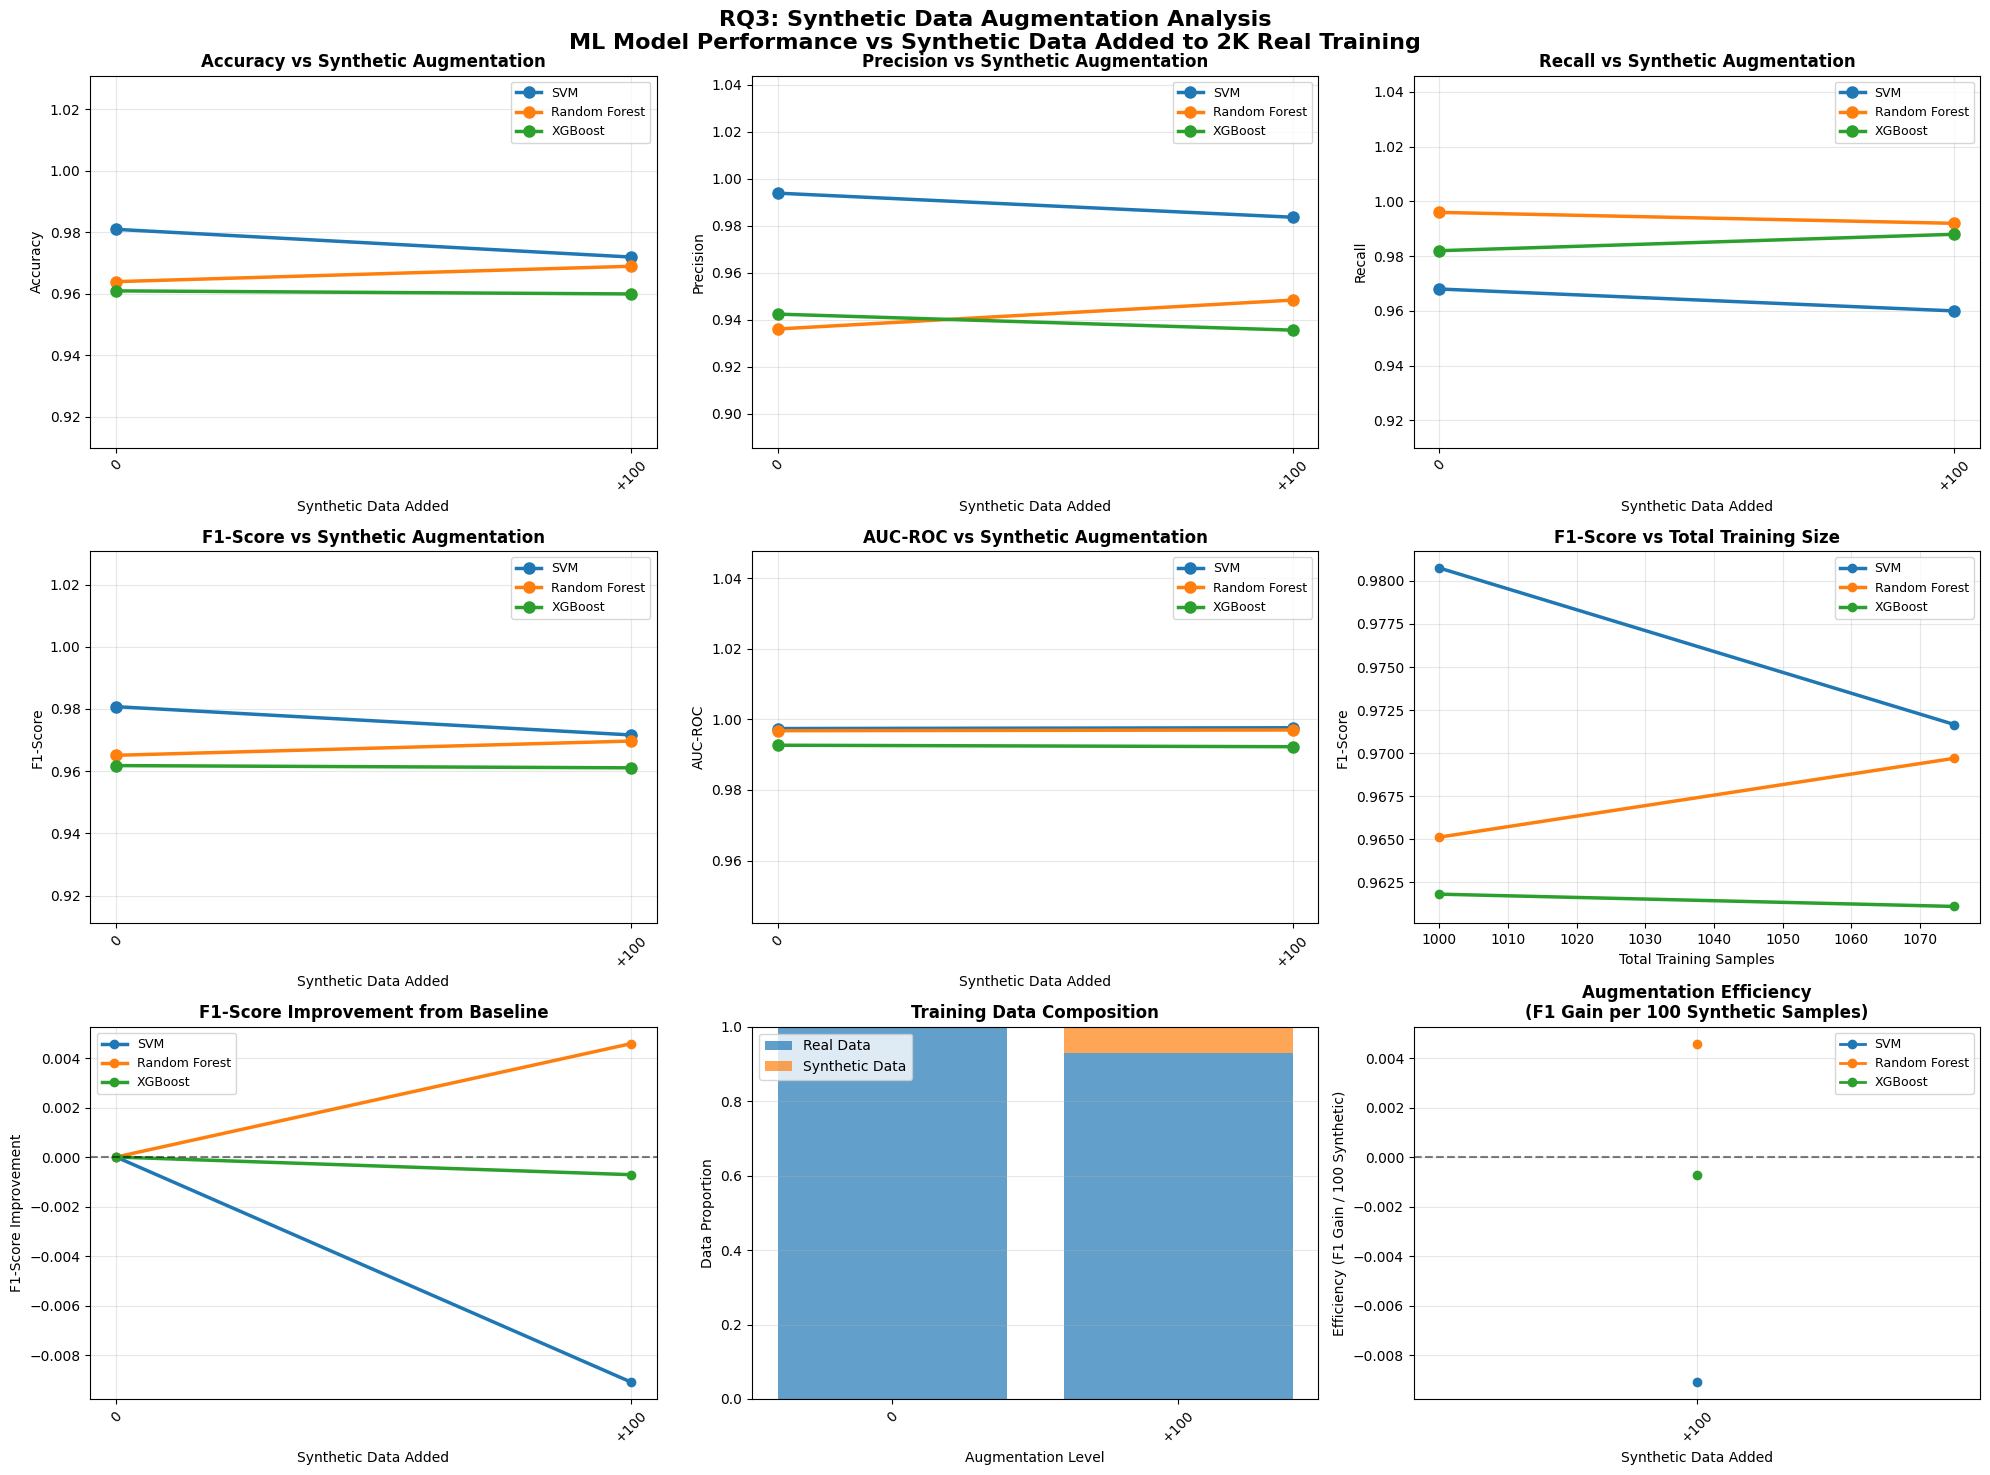

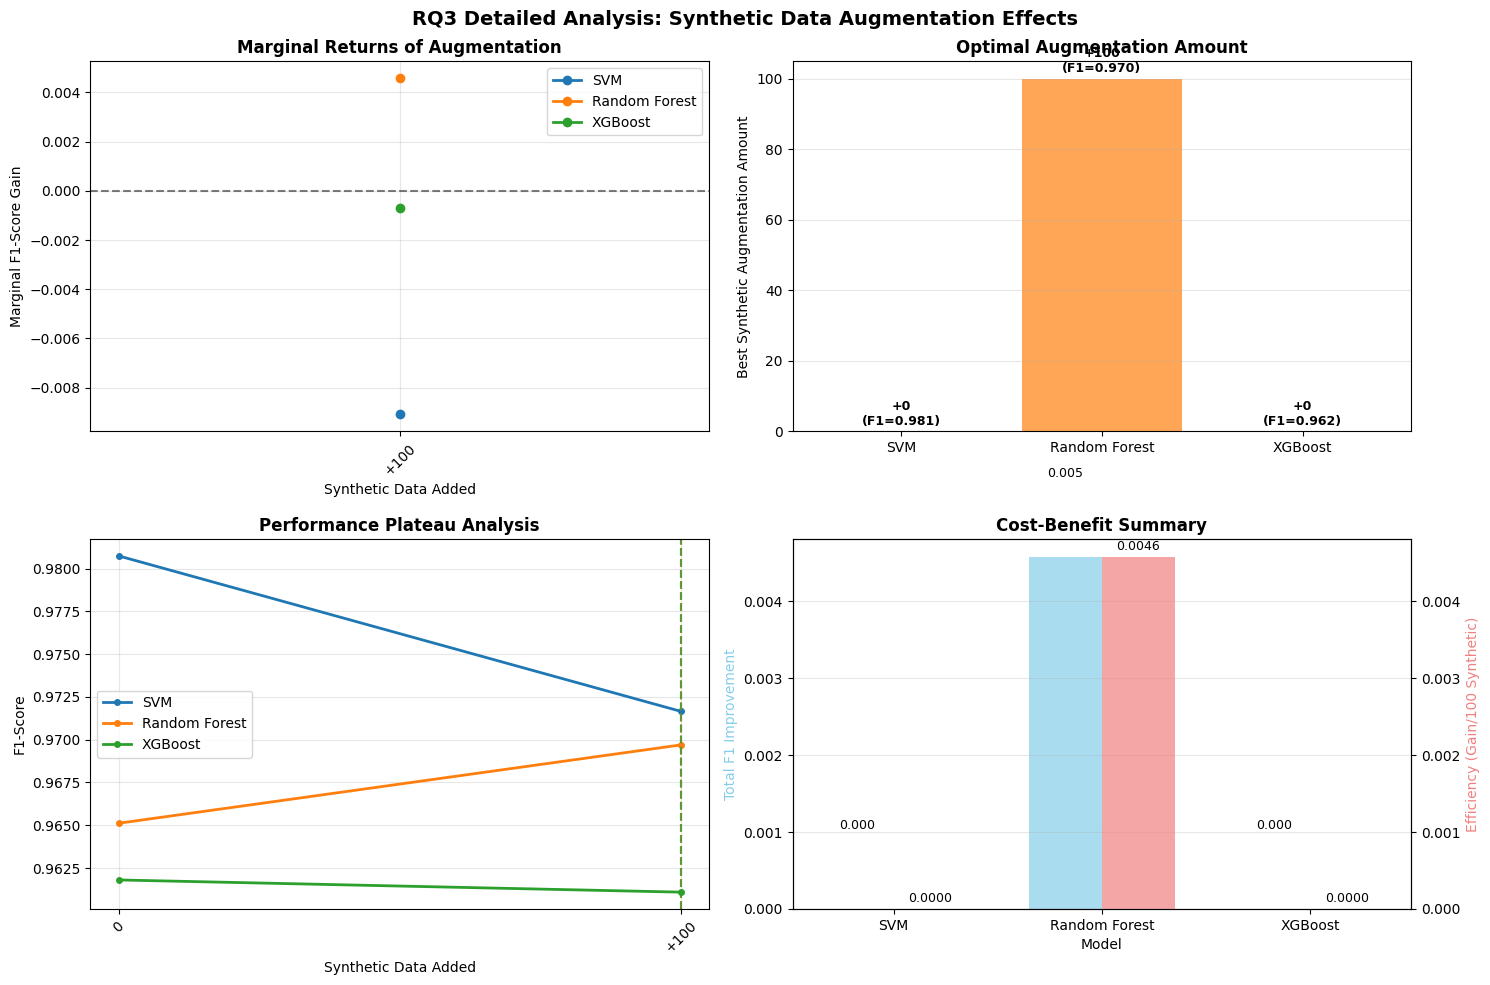


🔍 KEY FINDINGS - RQ3: SYNTHETIC DATA AUGMENTATION

🏆 BEST OVERALL PERFORMANCE:
   Model: SVM
   Augmentation: +0 synthetic samples
   Total training size: 1,000 samples
   F1-Score: 0.981
   Improvement from baseline: 0.012

📊 BASELINE vs BEST AUGMENTATION:
   SVM:
      Baseline (2K real): 0.981
      Best (+0 synthetic): 0.981
      Improvement: +0.000 (+0.0%) ❌ Degraded
   Random Forest:
      Baseline (2K real): 0.965
      Best (+100 synthetic): 0.970
      Improvement: +0.005 (+0.5%) ⚠️ Marginal
   XGBoost:
      Baseline (2K real): 0.962
      Best (+0 synthetic): 0.962
      Improvement: +0.000 (+0.0%) ❌ Degraded

🎯 OPTIMAL AUGMENTATION AMOUNTS:
   SVM: +0 synthetic samples
      Total training size: 1,000
      Best F1-Score: 0.981
   Random Forest: +100 synthetic samples
      Total training size: 1,075
      Best F1-Score: 0.970
   XGBoost: +0 synthetic samples
      Total training size: 1,000
      Best F1-Score: 0.962

📉 DIMINISHING RETURNS ANALYSIS:
   Point where additi

In [1]:
# RQ3: Synthetic Data Augmentation Analysis
# Research Question 3: How does adding synthetic data to real training data affect model performance?

import pandas as pd
import numpy as np
import gzip
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, 
                           precision_score, recall_score, f1_score, roc_auc_score, roc_curve)
import xgboost as xgb

# Visualization
plt.style.use('default')
sns.set_palette("husl")

print("🚀 Email Phishing Classification: Synthetic Data Augmentation Analysis")
print("=" * 80)
print("Research Question 3: How does adding synthetic data to real training data affect performance?")
print("Base: 2K real training data")
print("Augmentation: +0K, +0.1K, +0.2K, ..., +1.9K, +2K synthetic data")
print("Total training sizes: 2K to 4K samples")
print("Classifiers: SVM, Random Forest, XGBoost")
print("=" * 80)

# =============================================================================
# CONFIGURATION
# =============================================================================

# File paths
# TRAIN_FILE = "../raw/five_email_phishing_train.csv.gz"
# TEST_FILE = "../raw/five_email_phishing_test.csv.gz"
# SYNTHETIC_FILE = "../data/synthetic/five_email_phishing_synthetic.csv.gz"
TRAIN_FILE = "../raw/email_phishing_CEAS-08_train.csv.gz"
TEST_FILE = "../raw/email_phishing_CEAS-08_test.csv.gz"
# SYNTHETIC_FILE = "../data/synthetic/email_phishing_CEAS-08_synthetic.csv.gz"
SYNTHETIC_FILE = "../data/seeds-augment/email_phishing_CEAS-08_train_augment.csv.gz"

# Experimental configuration
BASE_REAL_SIZE = 1000  # Always use full N real training data
# SYNTHETIC_AUGMENT_AMOUNTS = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 
#                             1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000]
SYNTHETIC_AUGMENT_AMOUNTS = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
RANDOM_STATE = 42
CV_FOLDS = 5

# Text preprocessing parameters
MAX_FEATURES = 5000
MIN_DF = 2
MAX_DF = 0.95
NGRAM_RANGE = (1, 2)

print(f"📂 Data Files:")
print(f"   Real Training: {TRAIN_FILE}")
print(f"   Testing: {TEST_FILE}")
print(f"   Synthetic: {SYNTHETIC_FILE}")
print(f"\n🎯 Experimental Setup:")
print(f"   Base real training size: {BASE_REAL_SIZE:,} samples (constant)")
print(f"   Synthetic augmentation amounts: {SYNTHETIC_AUGMENT_AMOUNTS}")
print(f"   Total training sizes: {[BASE_REAL_SIZE + aug for aug in SYNTHETIC_AUGMENT_AMOUNTS]}")
print(f"   Cross-validation: {CV_FOLDS}-fold")
print(f"   Random state: {RANDOM_STATE}")

# =============================================================================
# 1. DATA LOADING AND PREPROCESSING
# =============================================================================

def load_compressed_data(file_path, description="data"):
    """Load compressed CSV data with error handling."""
    print(f"\n📥 Loading {description} from: {file_path}")
    
    try:
        with gzip.open(file_path, 'rt', encoding='utf-8') as f:
            df = pd.read_csv(f)
        
        print(f"   ✅ Loaded successfully!")
        print(f"   Shape: {df.shape}")
        print(f"   Columns: {list(df.columns)}")
        
        # Check label distribution
        if 'label' in df.columns:
            label_counts = df['label'].value_counts().sort_index()
            print(f"   Label distribution:")
            print(f"      Benign (0): {label_counts[0]:,} ({label_counts[0]/len(df)*100:.1f}%)")
            print(f"      Malicious (1): {label_counts[1]:,} ({label_counts[1]/len(df)*100:.1f}%)")
        
        return df
        
    except Exception as e:
        print(f"   ❌ Error loading {description}: {e}")
        raise

def preprocess_text(df):
    """Combine subject and body into single text feature."""
    print(f"\n🔤 Preprocessing text features for {len(df)} samples...")
    
    # Handle missing values
    df['subject'] = df['subject'].fillna('')
    df['body'] = df['body'].fillna('')
    
    # Combine subject and body
    df['combined_text'] = df['subject'] + ' ' + df['body']
    
    # Remove empty texts
    df = df[df['combined_text'].str.strip() != '']
    
    print(f"   ✅ Text preprocessing completed")
    print(f"   Final samples: {len(df):,}")
    
    return df

# Load all datasets
print("\n" + "="*60)
print("📊 LOADING DATASETS")
print("="*60)

real_train_df = load_compressed_data(TRAIN_FILE, "real training data")
test_df = load_compressed_data(TEST_FILE, "test data")
synthetic_df = load_compressed_data(SYNTHETIC_FILE, "synthetic data")

# Preprocess all datasets
real_train_df = preprocess_text(real_train_df.copy())
test_df = preprocess_text(test_df.copy())
synthetic_df = preprocess_text(synthetic_df.copy())

# =============================================================================
# 2. DATA VALIDATION FOR AUGMENTATION
# =============================================================================

def validate_augmentation_data():
    """Validate that we have sufficient data for augmentation experiments."""
    global BASE_REAL_SIZE  # Declare global at the beginning
    
    print("\n" + "="*60)
    print("🔍 DATA VALIDATION FOR AUGMENTATION")
    print("="*60)
    
    # Check if we have enough real training data
    print(f"\n📊 Real Training Data Availability:")
    print(f"   Available: {len(real_train_df):,} samples")
    print(f"   Required: {BASE_REAL_SIZE:,} samples")
    
    if len(real_train_df) < BASE_REAL_SIZE:
        print(f"   ⚠️  WARNING: Not enough real training data!")
        print(f"   Will use all available {len(real_train_df):,} samples as base")
        BASE_REAL_SIZE = len(real_train_df)
    else:
        print(f"   ✅ Sufficient real training data available")
    
    # Check synthetic data availability
    max_synthetic_needed = max(SYNTHETIC_AUGMENT_AMOUNTS)
    print(f"\n📊 Synthetic Data Availability:")
    print(f"   Available: {len(synthetic_df):,} samples")
    print(f"   Maximum needed: {max_synthetic_needed:,} samples")
    
    if len(synthetic_df) < max_synthetic_needed:
        print(f"   ⚠️  WARNING: Not enough synthetic data for full augmentation!")
        print(f"   Will limit experiments to available synthetic data")
        
        # Adjust synthetic amounts to available data
        available_amounts = [amt for amt in SYNTHETIC_AUGMENT_AMOUNTS if amt <= len(synthetic_df)]
        print(f"   Adjusted synthetic amounts: {available_amounts}")
        return available_amounts
    else:
        print(f"   ✅ Sufficient synthetic data for all experiments")
        return SYNTHETIC_AUGMENT_AMOUNTS
    
    # Check label compatibility
    print(f"\n📋 Label Compatibility Check:")
    real_labels = set(real_train_df['label'].unique())
    synthetic_labels = set(synthetic_df['label'].unique())
    test_labels = set(test_df['label'].unique())
    
    print(f"   Real training labels: {sorted(real_labels)}")
    print(f"   Synthetic labels: {sorted(synthetic_labels)}")
    print(f"   Test labels: {sorted(test_labels)}")
    
    if real_labels == synthetic_labels == test_labels:
        print(f"   ✅ All datasets have compatible labels")
    else:
        print(f"   ⚠️  WARNING: Label mismatch between datasets!")
    
    return SYNTHETIC_AUGMENT_AMOUNTS

# Validate data and get adjusted synthetic amounts
synthetic_amounts = validate_augmentation_data()

# =============================================================================
# 3. AUGMENTED DATASET CREATION STRATEGY
# =============================================================================

def create_augmented_dataset(real_df, synthetic_df, synthetic_amount, base_size=BASE_REAL_SIZE, random_state=42):
    """
    Create an augmented dataset by adding synthetic data to real training data.
    
    Parameters:
    - real_df: Real training data DataFrame
    - synthetic_df: Synthetic data DataFrame
    - synthetic_amount: Number of synthetic samples to add
    - base_size: Number of real samples to use as base
    - random_state: Random seed for reproducibility
    
    Returns:
    - Augmented DataFrame with real + synthetic data
    """
    print(f"\n🎯 Creating augmented dataset: {base_size:,} real + {synthetic_amount:,} synthetic...")
    
    np.random.seed(random_state)
    
    # Step 1: Select base real data (stratified sampling)
    real_benign = real_df[real_df['label'] == 0]
    real_malicious = real_df[real_df['label'] == 1]
    
    # Use stratified sampling to maintain class balance in real data
    target_real_benign = base_size // 2
    target_real_malicious = base_size - target_real_benign
    
    # Sample real data
    if len(real_benign) >= target_real_benign:
        sampled_real_benign = real_benign.sample(n=target_real_benign, random_state=random_state)
    else:
        print(f"   ⚠️  Not enough real benign samples! Using all {len(real_benign)} available")
        sampled_real_benign = real_benign
    
    if len(real_malicious) >= target_real_malicious:
        sampled_real_malicious = real_malicious.sample(n=target_real_malicious, random_state=random_state)
    else:
        print(f"   ⚠️  Not enough real malicious samples! Using all {len(real_malicious)} available")
        sampled_real_malicious = real_malicious
    
    # Combine real data
    base_real_data = pd.concat([sampled_real_benign, sampled_real_malicious], ignore_index=True)
    actual_real_count = len(base_real_data)
    
    print(f"   ✅ Base real data: {actual_real_count:,} samples")
    print(f"      Benign: {len(sampled_real_benign):,}, Malicious: {len(sampled_real_malicious):,}")
    
    # Step 2: Add synthetic augmentation data
    augmented_data = [base_real_data]
    actual_synthetic_count = 0
    
    if synthetic_amount > 0:
        synthetic_benign = synthetic_df[synthetic_df['label'] == 0]
        synthetic_malicious = synthetic_df[synthetic_df['label'] == 1]
        
        # Use stratified sampling for synthetic data too (maintain balance)
        target_synth_benign = synthetic_amount // 2
        target_synth_malicious = synthetic_amount - target_synth_benign
        
        # Sample synthetic data
        if len(synthetic_benign) >= target_synth_benign:
            sampled_synth_benign = synthetic_benign.sample(n=target_synth_benign, random_state=random_state+1)
        else:
            print(f"   ⚠️  Not enough synthetic benign samples! Using all {len(synthetic_benign)} available")
            sampled_synth_benign = synthetic_benign
        
        if len(synthetic_malicious) >= target_synth_malicious:
            sampled_synth_malicious = synthetic_malicious.sample(n=target_synth_malicious, random_state=random_state+2)
        else:
            print(f"   ⚠️  Not enough synthetic malicious samples! Using all {len(synthetic_malicious)} available")
            sampled_synth_malicious = synthetic_malicious
        
        # Combine synthetic data
        synthetic_augment_data = pd.concat([sampled_synth_benign, sampled_synth_malicious], ignore_index=True)
        actual_synthetic_count = len(synthetic_augment_data)
        
        print(f"   ✅ Synthetic augmentation: {actual_synthetic_count:,} samples")
        print(f"      Benign: {len(sampled_synth_benign):,}, Malicious: {len(sampled_synth_malicious):,}")
        
        augmented_data.append(synthetic_augment_data)
    else:
        print(f"   ✅ No synthetic augmentation (baseline experiment)")
    
    # Step 3: Combine and shuffle all data
    final_dataset = pd.concat(augmented_data, ignore_index=True)
    final_dataset = final_dataset.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    # Verify final composition
    final_size = len(final_dataset)
    final_labels = final_dataset['label'].value_counts().sort_index()
    synthetic_ratio = actual_synthetic_count / final_size if final_size > 0 else 0
    
    print(f"\n   ✅ Final augmented dataset: {final_size:,} samples")
    print(f"      Real: {actual_real_count:,} ({(1-synthetic_ratio):.1%})")
    print(f"      Synthetic: {actual_synthetic_count:,} ({synthetic_ratio:.1%})")
    print(f"      Labels - Benign: {final_labels[0]:,}, Malicious: {final_labels[1]:,}")
    
    return final_dataset, actual_real_count, actual_synthetic_count

# =============================================================================
# 4. MACHINE LEARNING MODELS
# =============================================================================

def initialize_models():
    """Initialize the three classifiers with optimized parameters."""
    models = {
        'SVM': SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            probability=True,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        ),
        'XGBoost': xgb.XGBClassifier(
            n_estimators=100,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            eval_metric='logloss',
            verbosity=0
        )
    }
    
    print("\n🤖 Initialized ML Models:")
    for name, model in models.items():
        print(f"   ✅ {name}: {type(model).__name__}")
    
    return models

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Train model and return comprehensive evaluation metrics."""
    
    print(f"   🔄 Training {model_name}...")
    
    if model_name == 'XGBoost':
        # Handle class imbalance for XGBoost
        class_weights = len(y_train) / (2 * np.bincount(y_train))
        sample_weights = np.where(y_train == 0, class_weights[0], class_weights[1])
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0
    }
    
    print(f"      ✅ {model_name} trained - F1: {metrics['f1']:.3f}, AUC: {metrics['auc']:.3f}")
    
    return metrics, y_pred, y_pred_proba

# =============================================================================
# 5. MAIN EXPERIMENT: RQ3 - SYNTHETIC DATA AUGMENTATION
# =============================================================================

def run_augmentation_experiment():
    """Run the main experiment for RQ3."""
    
    print("\n" + "="*80)
    print("🧪 EXPERIMENT RQ3: SYNTHETIC DATA AUGMENTATION ANALYSIS")
    print("="*80)
    
    # Initialize models
    models = initialize_models()
    
    # Initialize results storage
    results = {
        'synthetic_augment_amount': [],
        'total_training_size': [],
        'real_samples': [],
        'synthetic_samples': [],
        'model': [],
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': [],
        'auc': []
    }
    
    # Store detailed results
    detailed_results = {}
    
    # Text vectorization (fit on all available training data for consistency)
    print(f"\n📝 Setting up TF-IDF vectorization...")
    
    # Combine real and synthetic data for fitting vectorizer
    all_training_text = pd.concat([
        real_train_df['combined_text'],
        synthetic_df['combined_text']
    ], ignore_index=True)
    
    vectorizer = TfidfVectorizer(
        max_features=MAX_FEATURES,
        min_df=MIN_DF,
        max_df=MAX_DF,
        ngram_range=NGRAM_RANGE,
        stop_words='english'
    )
    
    # Fit vectorizer on all training data
    vectorizer.fit(all_training_text)
    
    # Vectorize test data (constant across all experiments)
    X_test = vectorizer.transform(test_df['combined_text'])
    y_test = test_df['label'].values
    
    print(f"   ✅ Vectorizer fitted - Features: {X_test.shape[1]:,}")
    print(f"   Test set: {X_test.shape[0]:,} samples")
    
    # Run experiments for each augmentation amount
    for i, aug_amount in enumerate(synthetic_amounts):
        total_size = BASE_REAL_SIZE + aug_amount
        print(f"\n{'='*60}")
        print(f"📊 EXPERIMENT {i+1}/{len(synthetic_amounts)}: +{aug_amount:,} SYNTHETIC AUGMENTATION")
        print(f"Total Training Size: {total_size:,} samples")
        print(f"{'='*60}")
        
        # Create augmented training dataset
        augmented_train, actual_real, actual_synthetic = create_augmented_dataset(
            real_train_df, synthetic_df, aug_amount, 
            BASE_REAL_SIZE, RANDOM_STATE + i
        )
        
        # Vectorize training data
        X_train = vectorizer.transform(augmented_train['combined_text'])
        y_train = augmented_train['label'].values
        
        print(f"\n   Training set: {X_train.shape[0]:,} samples, {X_train.shape[1]:,} features")
        print(f"   Composition: {actual_real:,} real + {actual_synthetic:,} synthetic")
        
        # Store experiment details
        detailed_results[aug_amount] = {
            'train_size': len(y_train),
            'real_count': actual_real,
            'synthetic_count': actual_synthetic,
            'synthetic_ratio': actual_synthetic / len(y_train),
            'models': {}
        }
        
        # Train and evaluate each model
        for model_name, _ in models.items():
            print(f"\n   🤖 Evaluating {model_name}...")
            
            # Create fresh model instance for each experiment
            if model_name == 'SVM':
                fresh_model = SVC(
                    kernel='rbf', C=1.0, gamma='scale', probability=True,
                    random_state=RANDOM_STATE, class_weight='balanced'
                )
            elif model_name == 'Random Forest':
                fresh_model = RandomForestClassifier(
                    n_estimators=100, max_depth=20, min_samples_split=5,
                    min_samples_leaf=2, random_state=RANDOM_STATE, class_weight='balanced'
                )
            else:  # XGBoost
                fresh_model = xgb.XGBClassifier(
                    n_estimators=100, max_depth=6, learning_rate=0.1,
                    subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE,
                    eval_metric='logloss', verbosity=0
                )
            
            # Train and evaluate
            metrics, y_pred, y_pred_proba = train_and_evaluate_model(
                fresh_model, X_train, y_train, X_test, y_test, model_name
            )
            
            # Store results
            results['synthetic_augment_amount'].append(aug_amount)
            results['total_training_size'].append(len(y_train))
            results['real_samples'].append(actual_real)
            results['synthetic_samples'].append(actual_synthetic)
            results['model'].append(model_name)
            results['accuracy'].append(metrics['accuracy'])
            results['precision'].append(metrics['precision'])
            results['recall'].append(metrics['recall'])
            results['f1'].append(metrics['f1'])
            results['auc'].append(metrics['auc'])
            
            # Store detailed results
            detailed_results[aug_amount]['models'][model_name] = {
                'metrics': metrics,
                'predictions': y_pred,
                'probabilities': y_pred_proba,
                'confusion_matrix': confusion_matrix(y_test, y_pred)
            }
            
            print(f"      📈 Results - Acc: {metrics['accuracy']:.3f}, "
                  f"Prec: {metrics['precision']:.3f}, Rec: {metrics['recall']:.3f}, "
                  f"F1: {metrics['f1']:.3f}, AUC: {metrics['auc']:.3f}")
    
    return pd.DataFrame(results), detailed_results

# Run the main experiment
results_df, detailed_results = run_augmentation_experiment()

# =============================================================================
# 6. RESULTS ANALYSIS AND VISUALIZATION
# =============================================================================

print("\n" + "="*80)
print("📊 RESULTS ANALYSIS - RQ3: SYNTHETIC DATA AUGMENTATION")
print("="*80)

# Display summary table
print("\n📋 Summary Results Table:")
print("-" * 100)

# Create pivot table for better readability
summary_table = results_df.pivot_table(
    index='synthetic_augment_amount', 
    columns='model', 
    values=['accuracy', 'precision', 'recall', 'f1', 'auc'],
    aggfunc='mean'
)

# Display with total training size for context
size_table = results_df.pivot_table(
    index='synthetic_augment_amount', 
    columns='model', 
    values='total_training_size',
    aggfunc='first'
)

print("Training Set Sizes:")
print(size_table.iloc[:, 0])  # All models have same size
print("\nPerformance Metrics:")
print(summary_table.round(3))

# =============================================================================
# 7. COMPREHENSIVE VISUALIZATIONS FOR RQ3
# =============================================================================

def create_rq3_comprehensive_plots():
    """Create comprehensive visualization plots for RQ3."""
    
    print(f"\n🎨 Creating comprehensive visualizations for RQ3...")
    
    # Define colors for each model
    colors = {'SVM': '#1f77b4', 'Random Forest': '#ff7f0e', 'XGBoost': '#2ca02c'}
    
    # Set up the plotting style
    plt.rcParams['figure.figsize'] = (20, 15)
    plt.rcParams['font.size'] = 10
    
    # Create subplots - 3 rows, 3 columns
    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    fig.suptitle('RQ3: Synthetic Data Augmentation Analysis\nML Model Performance vs Synthetic Data Added to 2K Real Training', 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Metrics to plot
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
    metric_titles = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
    
    # Plot each metric vs synthetic augmentation amount
    for idx, (metric, title) in enumerate(zip(metrics, metric_titles)):
        if idx < 6:  # We have 5 metrics for first 5 subplots
            row = idx // 3
            col = idx % 3
            ax = axes[row, col]
            
            # Plot lines for each model
            for model in results_df['model'].unique():
                model_data = results_df[results_df['model'] == model]
                ax.plot(model_data['synthetic_augment_amount'], model_data[metric], 
                       marker='o', linewidth=2.5, markersize=8, 
                       label=model, color=colors[model])
            
            ax.set_title(f'{title} vs Synthetic Augmentation', fontsize=12, fontweight='bold')
            ax.set_xlabel('Synthetic Data Added', fontsize=10)
            ax.set_ylabel(title, fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)
            
            # Format x-axis (show every 200 samples for readability)
            x_ticks = [amt for amt in synthetic_amounts if amt % 400 == 0 or amt in [0, max(synthetic_amounts)]]
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([f'+{amt}' if amt > 0 else '0' for amt in x_ticks], rotation=45)
            
            # Dynamic y-axis limits with buffer
            metric_values = []
            for model in results_df['model'].unique():
                model_data = results_df[results_df['model'] == model]
                metric_values.extend(model_data[metric].values)
            
            if metric_values:
                y_min = max(0, min(metric_values) - 0.05)
                y_max = min(1.05, max(metric_values) + 0.05)
                ax.set_ylim(y_min, y_max)
    
    # Training size vs performance
    ax = axes[1, 2]
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        ax.plot(model_data['total_training_size'], model_data['f1'], 
               marker='o', linewidth=2.5, markersize=6, 
               label=model, color=colors[model])
    
    ax.set_title('F1-Score vs Total Training Size', fontsize=12, fontweight='bold')
    ax.set_xlabel('Total Training Samples')
    ax.set_ylabel('F1-Score')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    
    # Performance improvement from baseline
    ax = axes[2, 0]
    
    # Calculate improvement from baseline (0 synthetic augmentation)
    baseline_performance = {}
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_augment_amount')
        baseline_f1 = model_data.iloc[0]['f1']  # 0 synthetic augmentation
        baseline_performance[model] = baseline_f1
        
        # Plot improvement
        improvements = []
        for _, row in model_data.iterrows():
            improvement = row['f1'] - baseline_f1
            improvements.append(improvement)
        
        ax.plot(model_data['synthetic_augment_amount'], improvements, 
               marker='o', linewidth=2.5, markersize=6, 
               label=model, color=colors[model])
    
    ax.set_title('F1-Score Improvement from Baseline', fontsize=12, fontweight='bold')
    ax.set_xlabel('Synthetic Data Added')
    ax.set_ylabel('F1-Score Improvement')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Format x-axis
    x_ticks = [amt for amt in synthetic_amounts if amt % 400 == 0 or amt in [0, max(synthetic_amounts)]]
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([f'+{amt}' if amt > 0 else '0' for amt in x_ticks], rotation=45)
    
    # Training composition visualization
    ax = axes[2, 1]
    
    # Show proportion of real vs synthetic in training data
    real_proportions = results_df['real_samples'] / results_df['total_training_size']
    synthetic_proportions = results_df['synthetic_samples'] / results_df['total_training_size']
    
    # Get unique data points for plotting
    unique_amounts = sorted(results_df['synthetic_augment_amount'].unique())
    real_props = []
    synth_props = []
    
    for amt in unique_amounts:
        amt_data = results_df[results_df['synthetic_augment_amount'] == amt].iloc[0]
        real_prop = amt_data['real_samples'] / amt_data['total_training_size']
        synth_prop = amt_data['synthetic_samples'] / amt_data['total_training_size']
        real_props.append(real_prop)
        synth_props.append(synth_prop)
    
    x_pos = range(len(unique_amounts))
    ax.bar(x_pos, real_props, label='Real Data', color='#1f77b4', alpha=0.7)
    ax.bar(x_pos, synth_props, bottom=real_props, label='Synthetic Data', color='#ff7f0e', alpha=0.7)
    
    ax.set_title('Training Data Composition', fontsize=12, fontweight='bold')
    ax.set_xlabel('Augmentation Level')
    ax.set_ylabel('Data Proportion')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    # Format x-axis to show augmentation amounts
    x_tick_indices = [i for i, amt in enumerate(unique_amounts) if amt % 400 == 0 or amt in [0, max(unique_amounts)]]
    x_tick_labels = [f'+{unique_amounts[i]}' if unique_amounts[i] > 0 else '0' for i in x_tick_indices]
    ax.set_xticks(x_tick_indices)
    ax.set_xticklabels(x_tick_labels, rotation=45)
    
    # Efficiency analysis (performance gain per 100 synthetic samples added)
    ax = axes[2, 2]
    
    # Calculate efficiency for each model
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_augment_amount')
        baseline_f1 = model_data.iloc[0]['f1']  # 0 synthetic augmentation
        
        efficiencies = []
        aug_amounts = []
        
        for _, row in model_data.iterrows():
            if row['synthetic_augment_amount'] > 0:  # Skip baseline
                performance_gain = row['f1'] - baseline_f1
                efficiency = performance_gain / (row['synthetic_augment_amount'] / 100)  # Per 100 samples
                efficiencies.append(efficiency)
                aug_amounts.append(row['synthetic_augment_amount'])
        
        if efficiencies:  # Only plot if we have data
            ax.plot(aug_amounts, efficiencies, 
                   marker='o', linewidth=2, markersize=6, 
                   label=model, color=colors[model])
    
    ax.set_title('Augmentation Efficiency\n(F1 Gain per 100 Synthetic Samples)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Synthetic Data Added')
    ax.set_ylabel('Efficiency (F1 Gain / 100 Synthetic)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Format x-axis
    if len(synthetic_amounts) > 1:
        x_ticks = [amt for amt in synthetic_amounts[1:] if amt % 400 == 0 or amt == max(synthetic_amounts)]
        ax.set_xticks(x_ticks)
        ax.set_xticklabels([f'+{amt}' for amt in x_ticks], rotation=45)
    
    plt.tight_layout()
    plt.show()

def create_detailed_rq3_analysis():
    """Create detailed analysis plots specific to RQ3."""
    
    # Define colors for each model
    colors = {'SVM': '#1f77b4', 'Random Forest': '#ff7f0e', 'XGBoost': '#2ca02c'}
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('RQ3 Detailed Analysis: Synthetic Data Augmentation Effects', fontsize=14, fontweight='bold')
    
    # 1. Marginal returns analysis (performance gain vs amount added)
    ax1 = axes[0, 0]
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_augment_amount')
        
        # Calculate marginal returns (difference between consecutive points)
        marginal_returns = []
        augment_points = []
        
        for i in range(1, len(model_data)):
            prev_f1 = model_data.iloc[i-1]['f1']
            curr_f1 = model_data.iloc[i]['f1']
            marginal_gain = curr_f1 - prev_f1
            marginal_returns.append(marginal_gain)
            augment_points.append(model_data.iloc[i]['synthetic_augment_amount'])
        
        if marginal_returns:
            ax1.plot(augment_points, marginal_returns, 
                    marker='o', linewidth=2, markersize=6, 
                    label=model, color=colors[model])
    
    ax1.set_title('Marginal Returns of Augmentation', fontweight='bold')
    ax1.set_xlabel('Synthetic Data Added')
    ax1.set_ylabel('Marginal F1-Score Gain')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Format x-axis
    if len(synthetic_amounts) > 1:
        x_ticks = [amt for amt in synthetic_amounts[1:] if amt % 400 == 0 or amt == max(synthetic_amounts)]
        ax1.set_xticks(x_ticks)
        ax1.set_xticklabels([f'+{amt}' for amt in x_ticks], rotation=45)
    
    # 2. Optimal augmentation point for each model
    ax2 = axes[0, 1]
    
    # Find best augmentation amount for each model
    best_augments = {}
    best_f1s = {}
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        best_idx = model_data['f1'].idxmax()
        best_augments[model] = model_data.loc[best_idx, 'synthetic_augment_amount']
        best_f1s[model] = model_data.loc[best_idx, 'f1']
    
    models = list(best_augments.keys())
    augments = [best_augments[model] for model in models]
    f1s = [best_f1s[model] for model in models]
    colors_list = [colors[model] for model in models]
    
    bars = ax2.bar(models, augments, color=colors_list, alpha=0.7)
    ax2.set_title('Optimal Augmentation Amount', fontweight='bold')
    ax2.set_ylabel('Best Synthetic Augmentation Amount')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add F1-score labels on bars
    for bar, aug, f1 in zip(bars, augments, f1s):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + max(augments)*0.01,
                f'+{int(aug)}\n(F1={f1:.3f})', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # 3. Performance plateau analysis
    ax3 = axes[1, 0]
    
    # Calculate when performance plateaus (derivative becomes very small)
    plateau_points = {}
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_augment_amount')
        
        # Find where improvement becomes less than 0.005 F1-score
        plateau_threshold = 0.005
        plateau_found = False
        plateau_point = None
        
        for i in range(1, len(model_data)):
            prev_f1 = model_data.iloc[i-1]['f1']
            curr_f1 = model_data.iloc[i]['f1']
            improvement = curr_f1 - prev_f1
            
            if improvement < plateau_threshold and not plateau_found:
                plateau_point = model_data.iloc[i]['synthetic_augment_amount']
                plateau_found = True
                break
        
        if plateau_point is None:
            plateau_point = max(synthetic_amounts)  # No plateau found
        
        plateau_points[model] = plateau_point
        
        # Plot the performance curve with plateau point marked
        ax3.plot(model_data['synthetic_augment_amount'], model_data['f1'], 
                marker='o', linewidth=2, markersize=4, 
                label=model, color=colors[model])
        
        # Mark plateau point
        ax3.axvline(x=plateau_point, color=colors[model], linestyle='--', alpha=0.7)
    
    ax3.set_title('Performance Plateau Analysis', fontweight='bold')
    ax3.set_xlabel('Synthetic Data Added')
    ax3.set_ylabel('F1-Score')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Format x-axis
    x_ticks = [amt for amt in synthetic_amounts if amt % 400 == 0 or amt in [0, max(synthetic_amounts)]]
    ax3.set_xticks(x_ticks)
    ax3.set_xticklabels([f'+{amt}' if amt > 0 else '0' for amt in x_ticks], rotation=45)
    
    # 4. Cost-benefit summary
    ax4 = axes[1, 1]
    
    # Calculate total improvement and efficiency for each model
    summary_data = []
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_augment_amount')
        baseline_f1 = model_data.iloc[0]['f1']
        max_f1 = model_data['f1'].max()
        best_aug_amount = best_augments[model]
        
        total_improvement = max_f1 - baseline_f1
        efficiency = total_improvement / (best_aug_amount / 100) if best_aug_amount > 0 else 0
        
        summary_data.append({
            'Model': model,
            'Total_Improvement': total_improvement,
            'Best_Aug_Amount': best_aug_amount,
            'Efficiency': efficiency
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Create a dual-axis plot
    ax4_twin = ax4.twinx()
    
    x_pos = range(len(summary_df))
    width = 0.35
    
    bars1 = ax4.bar([x - width/2 for x in x_pos], summary_df['Total_Improvement'], 
                   width, label='Total F1 Improvement', color='skyblue', alpha=0.7)
    bars2 = ax4_twin.bar([x + width/2 for x in x_pos], summary_df['Efficiency'], 
                        width, label='Efficiency', color='lightcoral', alpha=0.7)
    
    ax4.set_title('Cost-Benefit Summary', fontweight='bold')
    ax4.set_xlabel('Model')
    ax4.set_ylabel('Total F1 Improvement', color='skyblue')
    ax4_twin.set_ylabel('Efficiency (Gain/100 Synthetic)', color='lightcoral')
    
    ax4.set_xticks(x_pos)
    ax4.set_xticklabels(summary_df['Model'])
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, val in zip(bars1, summary_df['Total_Improvement']):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    
    for bar, val in zip(bars2, summary_df['Efficiency']):
        height = bar.get_height()
        ax4_twin.text(bar.get_x() + bar.get_width()/2., height + max(summary_df['Efficiency'])*0.01,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()

# Create visualizations
create_rq3_comprehensive_plots()
create_detailed_rq3_analysis()

# =============================================================================
# 8. KEY FINDINGS AND INSIGHTS FOR RQ3
# =============================================================================

def analyze_rq3_key_findings():
    """Analyze and report key findings from RQ3."""
    
    print("\n" + "="*80)
    print("🔍 KEY FINDINGS - RQ3: SYNTHETIC DATA AUGMENTATION")
    print("="*80)
    
    # 1. Best performing augmentation overall
    best_overall = results_df.loc[results_df['f1'].idxmax()]
    baseline_avg = results_df[results_df['synthetic_augment_amount'] == 0]['f1'].mean()
    
    print(f"\n🏆 BEST OVERALL PERFORMANCE:")
    print(f"   Model: {best_overall['model']}")
    print(f"   Augmentation: +{best_overall['synthetic_augment_amount']:,} synthetic samples")
    print(f"   Total training size: {best_overall['total_training_size']:,} samples")
    print(f"   F1-Score: {best_overall['f1']:.3f}")
    print(f"   Improvement from baseline: {best_overall['f1'] - baseline_avg:.3f}")
    
    # 2. Baseline vs best augmentation comparison
    print(f"\n📊 BASELINE vs BEST AUGMENTATION:")
    baseline_results = results_df[results_df['synthetic_augment_amount'] == 0]
    
    for model in results_df['model'].unique():
        model_baseline = baseline_results[baseline_results['model'] == model]['f1'].iloc[0]
        model_data = results_df[results_df['model'] == model]
        model_best = model_data['f1'].max()
        best_aug_idx = model_data['f1'].idxmax()
        best_aug_amount = model_data.loc[best_aug_idx, 'synthetic_augment_amount']
        
        improvement = model_best - model_baseline
        improvement_pct = (improvement / model_baseline) * 100
        
        status = "✅ Improved" if improvement > 0.01 else "⚠️ Marginal" if improvement > 0 else "❌ Degraded"
        
        print(f"   {model}:")
        print(f"      Baseline (2K real): {model_baseline:.3f}")
        print(f"      Best (+{best_aug_amount:,} synthetic): {model_best:.3f}")
        print(f"      Improvement: {improvement:+.3f} ({improvement_pct:+.1f}%) {status}")
    
    # 3. Optimal augmentation amounts
    print(f"\n🎯 OPTIMAL AUGMENTATION AMOUNTS:")
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        best_idx = model_data['f1'].idxmax()
        best_aug = model_data.loc[best_idx, 'synthetic_augment_amount']
        best_f1 = model_data.loc[best_idx, 'f1']
        total_size = model_data.loc[best_idx, 'total_training_size']
        
        print(f"   {model}: +{best_aug:,} synthetic samples")
        print(f"      Total training size: {total_size:,}")
        print(f"      Best F1-Score: {best_f1:.3f}")
    
    # 4. Diminishing returns analysis
    print(f"\n📉 DIMINISHING RETURNS ANALYSIS:")
    print("   Point where additional synthetic data provides < 0.005 F1 improvement:")
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_augment_amount')
        
        plateau_threshold = 0.005
        plateau_point = None
        
        for i in range(1, len(model_data)):
            prev_f1 = model_data.iloc[i-1]['f1']
            curr_f1 = model_data.iloc[i]['f1']
            improvement = curr_f1 - prev_f1
            
            if improvement < plateau_threshold:
                plateau_point = model_data.iloc[i]['synthetic_augment_amount']
                break
        
        if plateau_point is None:
            print(f"   {model}: No plateau found (continues improving)")
        else:
            print(f"   {model}: Plateau at +{plateau_point:,} synthetic samples")
    
    # 5. Efficiency analysis (best return on investment)
    print(f"\n💰 EFFICIENCY ANALYSIS:")
    print("   (Best F1 improvement per 100 synthetic samples added)")
    
    most_efficient_model = None
    best_efficiency = -float('inf')
    
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model].sort_values('synthetic_augment_amount')
        baseline_f1 = model_data.iloc[0]['f1']
        
        best_efficiency_for_model = -float('inf')
        best_efficiency_amount = 0
        
        for _, row in model_data.iterrows():
            if row['synthetic_augment_amount'] > 0:
                performance_gain = row['f1'] - baseline_f1
                efficiency = performance_gain / (row['synthetic_augment_amount'] / 100)
                
                if efficiency > best_efficiency_for_model:
                    best_efficiency_for_model = efficiency
                    best_efficiency_amount = row['synthetic_augment_amount']
        
        print(f"   {model}:")
        print(f"      Best efficiency: {best_efficiency_for_model:.4f} F1 gain per 100 synthetic")
        print(f"      At augmentation: +{best_efficiency_amount:,} samples")
        
        if best_efficiency_for_model > best_efficiency:
            best_efficiency = best_efficiency_for_model
            most_efficient_model = model
    
    print(f"\n   🥇 Most efficient model: {most_efficient_model}")
    
    # 6. Training size vs performance relationship
    print(f"\n📈 TRAINING SIZE vs PERFORMANCE:")
    
    # Calculate correlation between training size and performance
    correlations = {}
    for model in results_df['model'].unique():
        model_data = results_df[results_df['model'] == model]
        correlation = np.corrcoef(model_data['total_training_size'], model_data['f1'])[0, 1]
        correlations[model] = correlation
        
        trend = "Positive" if correlation > 0.3 else "Weak/None" if correlation > -0.3 else "Negative"
        print(f"   {model}: r = {correlation:.3f} ({trend} correlation)")
    
    # 7. Practical recommendations
    print(f"\n💡 PRACTICAL RECOMMENDATIONS:")
    
    # Overall recommendation based on average performance
    avg_performance_by_aug = results_df.groupby('synthetic_augment_amount')['f1'].mean()
    best_avg_aug = avg_performance_by_aug.idxmax()
    best_avg_f1 = avg_performance_by_aug.max()
    baseline_avg_f1 = avg_performance_by_aug.iloc[0]  # 0 augmentation
    
    overall_improvement = best_avg_f1 - baseline_avg_f1
    
    print(f"   🎯 OVERALL RECOMMENDATION:")
    if overall_improvement > 0.01:
        print(f"      ✅ Use synthetic augmentation: +{best_avg_aug:,} samples")
        print(f"      Expected improvement: {overall_improvement:.3f} F1-score")
        print(f"      Total training size: {BASE_REAL_SIZE + best_avg_aug:,} samples")
    else:
        print(f"      ⚠️  Synthetic augmentation shows minimal benefit")
        print(f"      Consider using 2K real data only")
    
    # Cost-effectiveness analysis
    print(f"\n   💸 COST-EFFECTIVENESS:")
    if best_avg_aug == 0:
        print(f"      Most cost-effective: Use only real data (2K samples)")
    else:
        cost_effectiveness = overall_improvement / (best_avg_aug / 100)
        print(f"      Cost-effectiveness: {cost_effectiveness:.4f} F1 gain per 100 synthetic samples")
        
        if cost_effectiveness > 0.01:
            print(f"      ✅ Synthetic augmentation is cost-effective")
        else:
            print(f"      ⚠️  Synthetic augmentation has low cost-effectiveness")
    
    # Model-specific recommendations
    print(f"\n   🎯 MODEL-SPECIFIC RECOMMENDATIONS:")
    for model in results_df['model'].unique():
        model_baseline = baseline_results[baseline_results['model'] == model]['f1'].iloc[0]
        model_data = results_df[results_df['model'] == model]
        model_best = model_data['f1'].max()
        best_aug_idx = model_data['f1'].idxmax()
        best_aug_amount = model_data.loc[best_aug_idx, 'synthetic_augment_amount']
        
        improvement = model_best - model_baseline
        
        if improvement > 0.01:
            print(f"      {model}: Use +{best_aug_amount:,} synthetic samples for {improvement:.3f} improvement")
        else:
            print(f"      {model}: Minimal benefit from augmentation, consider real data only")

# Run the analysis
analyze_rq3_key_findings()

# =============================================================================
# 9. RESEARCH QUESTION 3 SUMMARY
# =============================================================================

print(f"\n" + "="*80)
print("📝 RESEARCH QUESTION 3 - SUMMARY")
print("="*80)

print(f"\n🎯 RESEARCH QUESTION:")
print(f"   How does adding synthetic data to real training data affect model performance?")

print(f"\n📊 EXPERIMENTAL DESIGN:")
print(f"   • Base real training: {BASE_REAL_SIZE:,} samples (constant)")
print(f"   • Synthetic augmentation: {min(synthetic_amounts):,} to {max(synthetic_amounts):,} samples")
print(f"   • Total training sizes: {BASE_REAL_SIZE + min(synthetic_amounts):,} to {BASE_REAL_SIZE + max(synthetic_amounts):,} samples")
print(f"   • Models evaluated: SVM, Random Forest, XGBoost")
print(f"   • Evaluation metrics: Accuracy, Precision, Recall, F1-Score, AUC-ROC")

print(f"\n🔍 KEY INSIGHTS:")

# Find the best overall augmentation strategy
avg_performance_by_aug = results_df.groupby('synthetic_augment_amount')['f1'].mean()
best_aug_amount = avg_performance_by_aug.idxmax()
best_avg_f1 = avg_performance_by_aug.max()
baseline_avg_f1 = avg_performance_by_aug.iloc[0]

improvement = best_avg_f1 - baseline_avg_f1

print(f"   1. Best augmentation overall: +{best_aug_amount:,} synthetic samples")
print(f"   2. Average improvement: {improvement:.3f} F1-score ({improvement/baseline_avg_f1*100:.1f}%)")

# Find which models benefit most
max_improvements = {}
for model in results_df['model'].unique():
    model_baseline = results_df[(results_df['model'] == model) & 
                               (results_df['synthetic_augment_amount'] == 0)]['f1'].iloc[0]
    model_best = results_df[results_df['model'] == model]['f1'].max()
    max_improvements[model] = model_best - model_baseline

best_improving_model = max(max_improvements.keys(), key=lambda x: max_improvements[x])
worst_improving_model = min(max_improvements.keys(), key=lambda x: max_improvements[x])

print(f"   3. Most benefits from augmentation: {best_improving_model} (+{max_improvements[best_improving_model]:.3f})")
print(f"   4. Least benefits from augmentation: {worst_improving_model} (+{max_improvements[worst_improving_model]:.3f})")

# Practical conclusion
if improvement > 0.01:
    conclusion = "Synthetic augmentation is recommended"
else:
    conclusion = "Synthetic augmentation shows minimal benefit"

print(f"   5. Practical conclusion: {conclusion}")

print(f"\n✅ EXPERIMENT COMPLETED SUCCESSFULLY!")
print(f"   Total configurations tested: {len(results_df)}")
print(f"   Augmentation levels tested: {len(synthetic_amounts)}")
print(f"   Results stored in: results_df, detailed_results")

print(f"\n" + "="*80)